In [1]:
import sys
sys.path.append("..")

from data import (
    load_steel_plates_faults,
    load_full_dataset,
    get_feature_names,
    get_target_names,
)

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
X, y, = load_steel_plates_faults()

# Check sape of feature and target
print(X.shape)
print(y.shape)

(1941, 27)
(1941, 7)


In [3]:
data = load_full_dataset()

# check shape of data frame
data.shape

(1941, 34)

In [4]:
# Print five 5 rows
data.head()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,...,Luminosity_Index,SigmoidOfAreas,Minimum_of_Luminosity,Pastry,Z_Scratch,K_Scratch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,108,1687,...,-0.2913,0.5822,76,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,123,1687,...,-0.1756,0.2984,84,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,125,1623,...,-0.1228,0.2150,99,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,126,1353,...,-0.1568,0.5212,99,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,126,1353,...,-0.1992,1.0000,37,1,0,0,0,0,0,0


In [5]:
# Identify feature names
feature_names = get_feature_names()
feature_names

['X_Minimum',
 'X_Maximum',
 'Y_Minimum',
 'Y_Maximum',
 'Pixels_Areas',
 'X_Perimeter',
 'Y_Perimeter',
 'Sum_of_Luminosity',
 'Maximum_of_Luminosity',
 'Length_of_Conveyer',
 'TypeOfSteel_A300',
 'TypeOfSteel_A400',
 'Steel_Plate_Thickness',
 'Edges_Index',
 'Empty_Index',
 'Square_Index',
 'Outside_X_Index',
 'Edges_X_Index',
 'Edges_Y_Index',
 'Outside_Global_Index',
 'LogOfAreas',
 'Log_X_Index',
 'Log_Y_Index',
 'Orientation_Index',
 'Luminosity_Index',
 'SigmoidOfAreas',
 'Minimum_of_Luminosity']

In [6]:
# Identify target names
target_names = get_target_names()
target_names

['Pastry',
 'Z_Scratch',
 'K_Scratch',
 'Stains',
 'Dirtiness',
 'Bumps',
 'Other_Faults']

In [7]:
# Check for missing values
data.isnull().sum().sum()

np.int64(0)

In [ ]:
# Check for class imbalance

for target in target_names:
    counts = data[target].value_counts()
    print(counts)


Pastry
0    1783
1     158
Name: count, dtype: int64
Z_Scratch
0    1751
1     190
Name: count, dtype: int64
K_Scratch
0    1550
1     391
Name: count, dtype: int64
Stains
0    1869
1      72
Name: count, dtype: int64
Dirtiness
0    1886
1      55
Name: count, dtype: int64
Bumps
0    1539
1     402
Name: count, dtype: int64
Other_Faults
0    1268
1     673
Name: count, dtype: int64


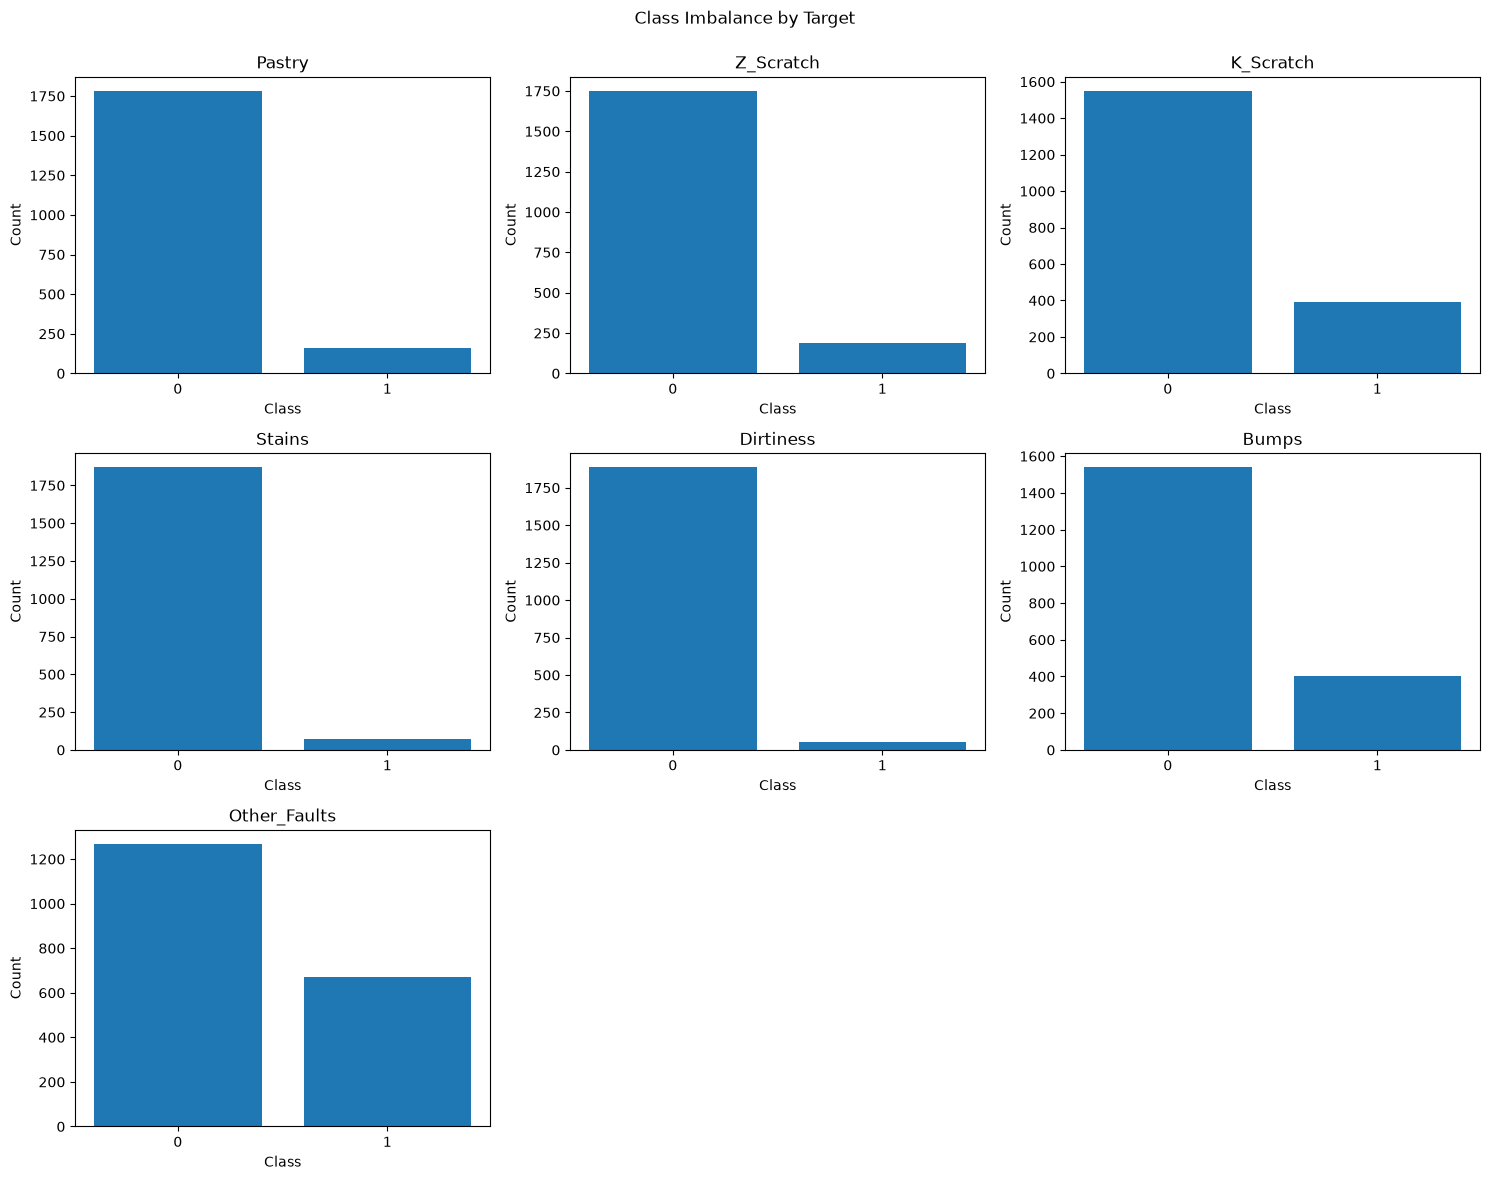

In [23]:
# plot class imbalance
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for ax, target in zip(axes, target_names):
    counts = data[target].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(target)
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")

plt.suptitle("Class Imbalance by Target\n")
for ax in axes[len(target_names):]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig("../outputs/figures/class_distribution.png", dpi=150)

In [ ]:
# Feature